Cell 1 — Install libraries

In [25]:
!pip install kagglehub[pandas-datasets] scikit-learn nltk matplotlib pandas

Cell 2 — Import all libraries

In [26]:
import kagglehub
import pandas as pd
import re
import nltk
import pickle
import matplotlib.pyplot as plt
from collections import Counter
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


Cell 3 — Load dataset

In [27]:
import os

path = kagglehub.dataset_download("kazanova/sentiment140")

csv_file = None
for f in os.listdir(path):
    if f.endswith(".csv"):
        csv_file = os.path.join(path, f)
        break

df = pd.read_csv(
    csv_file,
    encoding="latin-1",
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text']
)

print("Dataset loaded!")
print("Shape:", df.shape)
print(df.head())

Using Colab cache for faster access to the 'sentiment140' dataset.
Dataset loaded!
Shape: (1600000, 6)
   sentiment          id                          date     query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


Cell 4 — Check dataset

In [28]:
print("Total rows:", len(df))
print("Columns:", df.columns.tolist())
print("Sentiment values:", df['sentiment'].unique())
print("Sample tweet:", df['text'].iloc[0])

Total rows: 1600000
Columns: ['sentiment', 'id', 'date', 'query', 'user', 'text']
Sentiment values: [0 4]
Sample tweet: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D


Cell 5 — Download stopwords

In [29]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
print("Stopwords loaded! Total:", len(stop_words))

Stopwords loaded! Total: 198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cell 6 — Define cleaning function

In [30]:
def clean_tweet(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # remove # symbol
    text = re.sub(r'[^a-z\s]', '', text)              # keep letters only
    text = ' '.join(
        w for w in text.split() if w not in stop_words
    )                                                  # remove stopwords
    return text.strip()

# Test it on one tweet
sample = df['text'].iloc[0]
print("Original :", sample)
print("Cleaned  :", clean_tweet(sample))

Original : @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
Cleaned  : thats bummer shoulda got david carr third day


Cell 7 — Clean all tweets

In [31]:
df['clean_text'] = df['text'].apply(clean_tweet)
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 4 else 0)

print("Cleaning done!")
print(df[['text', 'clean_text', 'label']].head(3))

Cleaning done!
                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   

                                          clean_text  label  
0      thats bummer shoulda got david carr third day      0  
1  upset cant update facebook texting might cry r...      0  
2  dived many times ball managed save rest go bounds      0  


Cell 8 — Take a sample for faster training

In [32]:
sample_df = df.sample(n=200000, random_state=42)

X = sample_df['clean_text']
y = sample_df['label']

print("Sample size:", len(sample_df))
print("Positive tweets:", y.sum())
print("Negative tweets:", (y == 0).sum())

Sample size: 200000
Positive tweets: 100143
Negative tweets: 99857


Cell 9 — Split into train and test

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size :", len(X_train))
print("Testing size  :", len(X_test))

Training size : 160000
Testing size  : 40000


Cell 10 — Convert text to numbers (TF-IDF)

In [34]:
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("Vectorization done!")
print("Training matrix shape:", X_train_vec.shape)

Vectorization done!
Training matrix shape: (160000, 50000)


Cell 11 — Train the model

In [35]:
model = LogisticRegression(max_iter=300, C=1.0)
model.fit(X_train_vec, y_train)

print("Model trained successfully!")

Model trained successfully!


Cell 12 — Evaluate the model

In [36]:
preds = model.predict(X_test_vec)

print("Accuracy:", round(accuracy_score(y_test, preds) * 100, 2), "%")
print()
print(classification_report(y_test, preds, target_names=['Negative', 'Positive']))

Accuracy: 77.9 %

              precision    recall  f1-score   support

    Negative       0.79      0.76      0.78     20088
    Positive       0.77      0.80      0.78     19912

    accuracy                           0.78     40000
   macro avg       0.78      0.78      0.78     40000
weighted avg       0.78      0.78      0.78     40000



Cell 13 — Define brand analyzer function

In [37]:
def analyze_brand(brand_keyword, data, model, vectorizer, n=500):
    mask = data['clean_text'].str.contains(brand_keyword.lower(), na=False)
    brand_df = data[mask].copy().head(n)

    if brand_df.empty:
        print('No tweets found for: ' + brand_keyword)
        return None

    vecs = vectorizer.transform(brand_df['clean_text'])
    brand_df['predicted_sentiment'] = model.predict(vecs)
    brand_df['confidence'] = model.predict_proba(vecs).max(axis=1)

    total    = len(brand_df)
    positive = int(brand_df['predicted_sentiment'].sum())
    negative = total - positive
    score    = round(positive / total * 100, 1)

    print('Brand           : ' + brand_keyword.upper())
    print('Total mentions  : ' + str(total))
    print('Positive        : ' + str(positive) + ' (' + str(score) + '%)')
    print('Negative        : ' + str(negative) + ' (' + str(round(100 - score, 1)) + '%)')
    print('Reputation Score: ' + str(score) + ' / 100')
    return brand_df

print("Function defined!")

Function defined!


Cell 14 — Run brand analysis

In [38]:
# Change "apple" to any brand you want to track and the this show sentiment towards this brand
results = analyze_brand("apple", df, model, vectorizer)

Brand           : APPLE
Total mentions  : 500
Positive        : 135 (27.0%)
Negative        : 365 (73.0%)
Reputation Score: 27.0 / 100


Cell 15 — Plot the dashboard

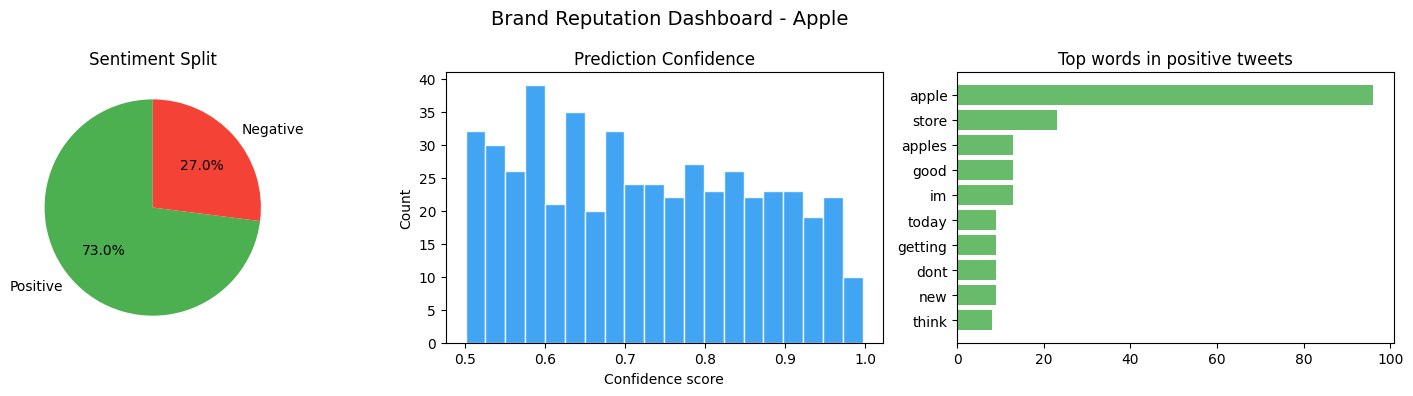

Chart saved as brand_dashboard.png


In [39]:
def plot_brand_dashboard(brand_df, brand_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Brand Reputation Dashboard - ' + brand_name.title(), fontsize=14)

    # Chart 1 — Sentiment pie
    counts = brand_df['predicted_sentiment'].value_counts()
    axes[0].pie(
        counts,
        labels=['Positive', 'Negative'],
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=90
    )
    axes[0].set_title('Sentiment Split')

    # Chart 2 — Confidence scores
    axes[1].hist(
        brand_df['confidence'], bins=20,
        color='#2196F3', edgecolor='white', alpha=0.85
    )
    axes[1].set_title('Prediction Confidence')
    axes[1].set_xlabel('Confidence score')
    axes[1].set_ylabel('Count')

    # Chart 3 — Top words in positive tweets
    pos_words = ' '.join(
        brand_df[brand_df['predicted_sentiment'] == 1]['clean_text']
    )
    word_freq = Counter(pos_words.split()).most_common(10)
    if word_freq:
        words, freqs = zip(*word_freq)
        axes[2].barh(list(words)[::-1], list(freqs)[::-1],
                     color='#4CAF50', alpha=0.85)
    axes[2].set_title('Top words in positive tweets')

    plt.tight_layout()
    plt.savefig('brand_dashboard.png', dpi=150)
    plt.show()
    print('Chart saved as brand_dashboard.png')

plot_brand_dashboard(results, "apple")

Cell 16 — Save the model

In [40]:
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'vectorizer': vectorizer}, f)

print("Model saved as sentiment_model.pkl")

Model saved as sentiment_model.pkl


Cell 17 — Score any new tweet

In [41]:
def score_tweet(tweet_text):
    cleaned = clean_tweet(tweet_text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = round(model.predict_proba(vec).max() * 100, 1)
    sentiment = 'POSITIVE' if pred == 1 else 'NEGATIVE'
    print('Tweet    : ' + tweet_text)
    print('Sentiment: ' + sentiment + ' (' + str(prob) + '% confidence)')
    print('-' * 50)

# Try your own sentences below
score_tweet("I love the new iPhone, battery life is amazing!")
score_tweet("Amazon delivery was terrible, package arrived broken.")
score_tweet("Tesla cars are overpriced and overhyped.")
score_tweet("Google Maps saved my trip, absolutely brilliant!")

Tweet    : I love the new iPhone, battery life is amazing!
Sentiment: POSITIVE (62.9% confidence)
--------------------------------------------------
Tweet    : Amazon delivery was terrible, package arrived broken.
Sentiment: NEGATIVE (89.4% confidence)
--------------------------------------------------
Tweet    : Tesla cars are overpriced and overhyped.
Sentiment: POSITIVE (53.6% confidence)
--------------------------------------------------
Tweet    : Google Maps saved my trip, absolutely brilliant!
Sentiment: POSITIVE (91.7% confidence)
--------------------------------------------------
